--- Stationarity Test (ADF) ---
ADF Statistic: -2.2570
p-value: 0.1862


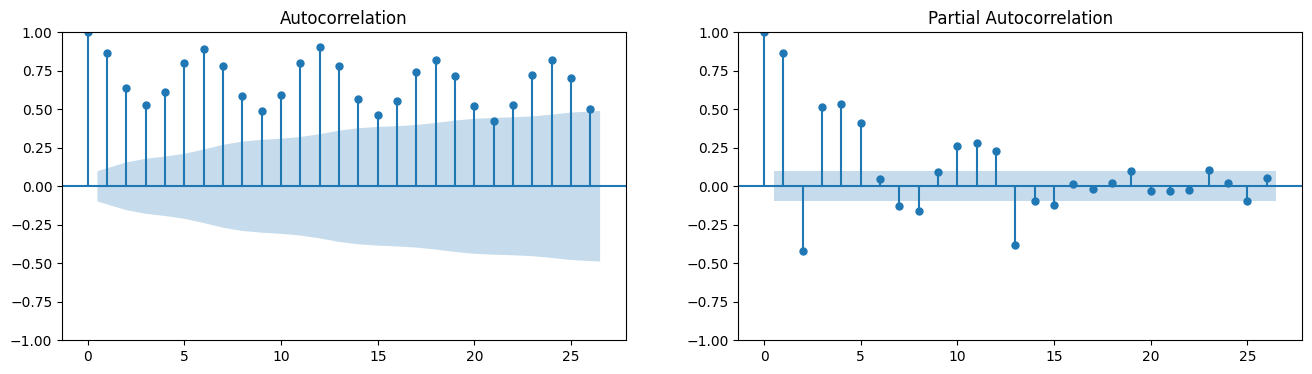


--- Training & Walk-Forward Validation ---
Mean Absolute Error (MAE): 7.10
Root Mean Squared Error (RMSE): 8.12

Model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  396
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1305.637
Date:                Mon, 20 Apr 2026   AIC                           2617.274
Time:                        19:17:01   BIC                           2629.211
Sample:                             0   HQIC                          2622.003
                                - 396                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0672      0.092      0.731      0.465      -0.113       0.247
ma

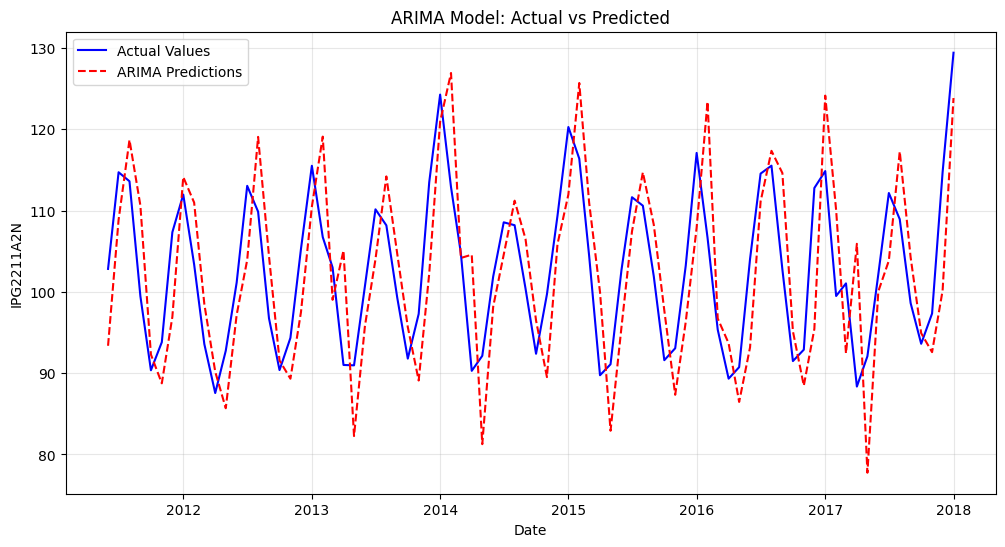

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. LOAD DATA
# Ensure your CSV has a Date column and a numerical Value column
df = pd.read_csv('Electric_production.csv')

# --- CONFIGURATION ---
DATE_COL = 'DATE'     # Change to your date column name
VALUE_COL = 'IPG2211A2N'   # Change to your target column name
# ---------------------

# 2. PRE-PROCESSING
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df.set_index(DATE_COL, inplace=True)
df.sort_index(inplace=True)

# 3. VISUALIZATION & STATIONARITY
print("--- Stationarity Test (ADF) ---")
result = adfuller(df[VALUE_COL])
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')

# Plot ACF/PACF to determine p and q
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df[VALUE_COL], ax=ax1)
plot_pacf(df[VALUE_COL], ax=ax2)
plt.show()

# 4. TRAIN/TEST SPLIT
# We use the first 80% for training and the last 20% for testing
train_size = int(len(df) * 0.8)
train, test = df[VALUE_COL][:train_size], df[VALUE_COL][train_size:]

# 5. MODEL IMPLEMENTATION (ARIMA)
# Order (p, d, q) - (1, 1, 1) is a common starting point
# p: AR (PACF), d: Differencing (ADF), q: MA (ACF)
history = [x for x in train]
predictions = []

print("\n--- Training & Walk-Forward Validation ---")
for t in range(len(test)):
    model = ARIMA(history, order=(1, 1, 1))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    
    # Observe the actual observation and add it to history for next prediction
    obs = test.iloc[t]
    history.append(obs)

# 6. EVALUATION METRICS
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print("\nModel Summary:")
print(model_fit.summary())

# 7. FINAL VISUALIZATION
plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label='Actual Values', color='blue')
plt.plot(test.index, predictions, label='ARIMA Predictions', color='red', linestyle='--')
plt.title('ARIMA Model: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel(VALUE_COL)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()